# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Anna Ramandhani
- **Email:** cdcc229d6x1604@student.devacademy.id
- **ID Dicoding:** CDCC229D6X1604

## Menentukan Pertanyaan Bisnis

- Bagaimana tren jumlah pesanan (order) pada platform e-commerce dari tahun 2016 hingga 2018 berdasarkan waktu (bulanan)?
- Bagaimana distribusi penggunaan metode pembayaran oleh pelanggan dan metode mana yang paling dominan dalam transaksi?


## Import Semua Packages/Library yang Digunakan

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

## Data Wrangling
Pada tahap ini dilakukan proses pengumpulan (gathering), penilaian (assessing), dan pembersihan (cleaning) data sebelum digunakan dalam analisis. Proses ini bertujuan untuk memastikan kualitas data sehingga hasil analisis yang diperoleh lebih akurat dan dapat dipercaya.

### Gathering Data
Pada tahap ini dilakukan pengumpulan data dari beberapa file CSV yang tersedia. Dataset yang digunakan berasal dari E-Commerce Public Dataset yang terdiri dari beberapa tabel seperti customers, orders, order items, payments, dan products.

In [8]:
from numpy._core.fromnumeric import prod
# Import dataset
customers_df = pd.read_csv('customers_dataset.csv')
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [9]:
orders_df = pd.read_csv('orders_dataset.csv')
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [10]:
order_items_df = pd.read_csv('order_items_dataset.csv')
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [11]:
order_payments_df = pd.read_csv('order_payments_dataset.csv')
order_payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [12]:
products_df = pd.read_csv('products_dataset.csv')
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


**Insight:**
- Dataset terdiri dari beberapa tabel yang saling berhubungan seperti customers, orders, dan payments
- Struktur data ini memungkinkan analisis yang lebih mendalam terkait perilaku pelanggan dan transaksi

### Assessing Data

Setelah data berhasil dimuat, tahap selanjutnya adalah melakukan penilaian (assessing) terhadap kualitas dan struktur data. Proses ini dilakukan pada seluruh dataset untuk mengidentifikasi permasalahan seperti missing values, duplikasi data, serta kesesuaian tipe data sebelum dilakukan proses pembersihan.

1. Orders Dataset

In [13]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [14]:
orders_df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [15]:
print("Jumlah duplikasi:", orders_df.duplicated().sum())
orders_df.describe()

Jumlah duplikasi: 0


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


2. Customers Dataset

In [16]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [17]:
customers_df.isna().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


In [18]:
print("Jumlah duplikasi:", customers_df.duplicated().sum())
customers_df.describe()

Jumlah duplikasi: 0


,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


3. Order Payments Dataset

In [19]:
order_payments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [20]:
order_payments_df.isna().sum()

,0
order_id,0
payment_sequential,0
payment_type,0
payment_installments,0
payment_value,0


In [21]:
print("Jumlah duplikasi:", order_payments_df.duplicated().sum())
order_payments_df.describe()

Jumlah duplikasi: 0


,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


4. Orders Items Dataset

In [22]:
order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [23]:
order_items_df.isna().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [24]:
print("Jumlah duplikasi:", order_items_df.duplicated().sum())
order_items_df.describe()

Jumlah duplikasi: 0


,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


5. Products Dataset

In [25]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [26]:
products_df.isna().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [27]:
print("Jumlah duplikasi:", products_df.duplicated().sum())
products_df.describe()

Jumlah duplikasi: 0


,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


| Dataset| Tipe data | Missing Value | Duplicate data | Inaccurate value |
|------------------|-------------|--------------------------------|------ | ---- |
| orders |- | Terdapat 160 missing values pada kolom order_approved_at, 1783 pada kolom order_delivered_carrier_date, dan 2965 pada order_delivered_customer_date | - | - | - |
| customers        | - | - | - | - |
| order_payments   | - | - | - | Terdapat inaccurate value pada kolom payment_value |
| order_items      | Terdapat kesalahan tipe data untuk kolom shipping_limit_date | - | - | - |
| products         | - | Terdapat 610 missing values pada kolom product_category_name, product_name_lenght, product_description_lenght, dan product_photos_qty, serta 2 missing values pada kolom product_weight_g, product_length_cm, product_height_cm, dan product_width_cm | - | - |

**Insight:**
- Dataset orders memiliki beberapa missing values pada kolom terkait proses pengiriman, yang kemungkinan disebabkan oleh pesanan yang belum selesai atau dibatalkan
- Dataset customers tidak menunjukkan adanya permasalahan kualitas data sehingga dapat langsung digunakan untuk analisis
- Dataset order_payments terindikasi memiliki nilai yang menyimpang pada kolom payment_value, yang perlu diperhatikan sebagai potensi outlier
- Dataset order_items memiliki kesalahan tipe data pada kolom shipping_limit_date yang perlu dikonversi ke format datetime untuk analisis berbasis waktu
- Dataset products memiliki cukup banyak missing values pada beberapa kolom atribut produk, yang berpotensi mempengaruhi analisis terkait karakteristik produk

### Cleaning Data
Pada tahap ini dilakukan proses pembersihan data berdasarkan permasalahan yang ditemukan pada tahap assessing data. Proses ini meliputi penanganan missing values, perbaikan tipe data, serta penyesuaian nilai yang tidak sesuai.

### 1. Menangani Missing Value pada Dataset Orders

Berdasarkan hasil assessing data, terdapat missing values pada beberapa kolom seperti order_approved_at, order_delivered_carrier_date, dan order_delivered_customer_date.

Sebelum menentukan metode penanganan, dilakukan pengecekan terhadap baris data yang mengandung missing values untuk memahami karakteristik data tersebut.

In [28]:
orders_df[orders_df['order_approved_at'].isna()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
1130,00b1cb0320190ca0daa2c88b35206009,3532ba38a3fd242259a514ac2b6ae6b6,canceled,2018-08-28 15:26:39,NaN,NaN,NaN,2018-09-12 00:00:00
1801,ed3efbd3a87bea76c2812c66a0b32219,191984a8ba4cbb2145acb4fe35b69664,canceled,2018-09-20 13:54:16,NaN,NaN,NaN,2018-10-17 00:00:00
1868,df8282afe61008dc26c6c31011474d02,aa797b187b5466bc6925aaaa4bb3bed1,canceled,2017-03-04 12:14:30,NaN,NaN,NaN,2017-04-10 00:00:00
2029,8d4c637f1accf7a88a4555f02741e606,b1dd715db389a2077f43174e7a675d07,canceled,2018-08-29 16:27:49,NaN,NaN,NaN,2018-09-13 00:00:00
2161,7a9d4c7f9b068337875b95465330f2fc,7f71ae48074c0cfec9195f88fcbfac55,canceled,2017-05-01 16:12:39,NaN,NaN,NaN,2017-05-30 00:00:00
...,...,...,...,...,...,...,...,...
97696,5a00b4d35edffc56b825c3646a99ba9d,6a3bdf004ca96338fb5fad1b8d93c2e6,canceled,2017-07-02 15:38:46,NaN,NaN,NaN,2017-07-25 00:00:00
98415,227c804e2a44760671a6a5697ea549e4,62e7477e75e542243ee62a0ba73f410f,canceled,2017-09-28 15:02:56,NaN,NaN,NaN,2017-10-16 00:00:00
98909,e49e7ce1471b4693482d40c2bd3ad196,e4e7ab3f449aeb401f0216f86c2104db,canceled,2018-08-07 11:16:28,NaN,NaN,NaN,2018-08-10 00:00:00
99283,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,NaN,NaN,NaN,2018-10-01 00:00:00


Berdasarkan hasil pengecekan, baris data yang memiliki missing values masih mengandung informasi penting seperti order_id dan customer_id. Namun, karena kolom yang kosong berkaitan dengan proses pengiriman, data tersebut kemungkinan merupakan pesanan yang belum selesai atau dibatalkan

Pada kasus ini, metode dropping dipilih untuk menangani missing values, karena data yang tidak memiliki informasi pengiriman lengkap tidak relevan untuk analisis tren pesanan yang berfokus pada transaksi yang telah selesai

In [29]:
orders_df = orders_df.dropna(subset=[
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date'
])

orders_df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,0
order_delivered_carrier_date,0
order_delivered_customer_date,0
order_estimated_delivery_date,0


Insight:
- Missing values pada dataset orders telah ditangani menggunakan metode dropping.
- Data yang tidak memiliki informasi pengiriman dihapus karena tidak relevan dengan analisis yang dilakukan.
- Dataset kini hanya berisi transaksi yang memiliki informasi lengkap.

### 2. Menangani Inaccurate Value pada Dataset Order Payments

Berdasarkan hasil assessing data, ditemukan nilai maksimum pada kolom payment_value yang jauh lebih tinggi dibandingkan rata-rata. Hal ini mengindikasikan adanya kemungkinan inaccurate value akibat kesalahan input (human error).

In [30]:
order_payments_df[order_payments_df.payment_value == order_payments_df.payment_value.max()]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
52107,03caa2c082116e1d31e67e9ae3700499,1,credit_card,1,13664.08


Berdasarkan hasil pengecekan, nilai maksimum pada kolom payment_value memiliki selisih yang sangat besar dibandingkan nilai rata-rata, sehingga berpotensi sebagai nilai yang tidak representatif.

Untuk mengatasi hal ini, nilai maksimum akan diganti menggunakan nilai median agar tidak mempengaruhi distribusi data secara signifikan.

In [31]:
max_value = order_payments_df['payment_value'].max()
median_value = order_payments_df['payment_value'].median()

order_payments_df['payment_value'].replace(max_value, median_value, inplace=True)

/tmp/ipykernel_444/3031321584.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  order_payments_df['payment_value'].replace(max_value, median_value, inplace=True)


In [32]:
order_payments_df.describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,153.969813
std,0.706584,2.687051,213.416823
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.830000
max,29.000000,24.000000,7274.880000


Insight:
- Nilai ekstrem pada kolom payment_value telah ditangani dengan metode imputation.
- Nilai maksimum diganti dengan median untuk menjaga distribusi data tetap stabil.
- Setelah perbaikan, nilai maksimum menjadi lebih representatif dan tidak terlalu mempengaruhi analisis statistik.

### 3. Menangani Kesalahan Tipe Data pada Dataset Order Items

Berdasarkan hasil assessing data, diketahui bahwa terdapat kesalahan tipe data pada kolom shipping_limit_date yang masih bertipe object. Kolom ini seharusnya bertipe datetime karena merepresentasikan informasi waktu

In [33]:
datetime_columns = ["shipping_limit_date"]

for column in datetime_columns:
    order_items_df[column] = pd.to_datetime(order_items_df[column])

In [34]:
order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


Insight:
- Kolom shipping_limit_date telah berhasil dikonversi dari tipe object menjadi datetime.
- Perubahan ini memungkinkan analisis berbasis waktu dilakukan dengan lebih akurat.
- Dataset order_items kini siap digunakan untuk tahap analisis selanjutnya.

### 4. Menangani Missing Value pada Dataset Products

Berdasarkan hasil assessing data, ditemukan missing values pada beberapa kolom seperti product_category_name, product_name_lenght, product_description_lenght, product_photos_qty, serta beberapa kolom numerik lainnya.

Sebelum menentukan metode penanganan, dilakukan pengecekan terhadap baris data yang mengandung missing values.

In [35]:
products_df[products_df.product_category_name.isna()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0
...,...,...,...,...,...,...,...,...,...
32515,b0a0c5dd78e644373b199380612c350a,NaN,NaN,NaN,NaN,1800.0,30.0,20.0,70.0
32589,10dbe0fbaa2c505123c17fdc34a63c56,NaN,NaN,NaN,NaN,800.0,30.0,10.0,23.0
32616,bd2ada37b58ae94cc838b9c0569fecd8,NaN,NaN,NaN,NaN,200.0,21.0,8.0,16.0
32772,fa51e914046aab32764c41356b9d4ea4,NaN,NaN,NaN,NaN,1300.0,45.0,16.0,45.0


Berdasarkan hasil pengecekan, baris data yang mengandung missing values masih memiliki informasi penting seperti product_id. Oleh karena itu, data tersebut tidak sebaiknya dihapus.

Pada kasus ini, metode imputation digunakan untuk menangani missing values agar tidak menghilangkan informasi penting dalam dataset.

In [36]:
products_df['product_category_name'].fillna(
    products_df['product_category_name'].mode()[0],
    inplace=True
)

/tmp/ipykernel_444/2266427335.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products_df['product_category_name'].fillna(


In [37]:
num_cols = [
    'product_name_lenght',
    'product_description_lenght',
    'product_photos_qty',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]

for col in num_cols:
    products_df[col].fillna(products_df[col].median(), inplace=True)

/tmp/ipykernel_444/2704630125.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products_df[col].fillna(products_df[col].median(), inplace=True)


In [38]:
products_df.isna().sum()

,0
product_id,0
product_category_name,0
product_name_lenght,0
product_description_lenght,0
product_photos_qty,0
product_weight_g,0
product_length_cm,0
product_height_cm,0
product_width_cm,0


Insight:
- Missing values pada dataset products ditangani menggunakan metode imputation.
- Kolom kategorikal diisi dengan nilai yang paling dominan, sedangkan kolom numerik diisi menggunakan median.
- Pendekatan ini dilakukan untuk mempertahankan informasi dalam dataset tanpa mengurangi jumlah data.

## Exploratory Data Analysis (EDA)
Pada tahap ini dilakukan eksplorasi data untuk memahami karakteristik dataset yang digunakan. Proses ini membantu dalam menemukan pola, hubungan, serta insight awal sebelum menjawab pertanyaan bisnis.

### Eksplorasi Data customers_df

In [39]:
customers_df.describe(include="all")

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


In [40]:
customers_df.groupby(by="customer_city").customer_id.nunique().sort_values(ascending=False)

,customer_id
customer_city,
sao paulo,15540
rio de janeiro,6882
belo horizonte,2773
brasilia,2131
curitiba,1521
...,...
agisse,1
vieiras,1
bertopolis,1


In [41]:
customers_df.groupby(by="customer_state").customer_id.nunique().sort_values(ascending=False)

,customer_id
customer_state,
SP,41746
RJ,12852
MG,11635
RS,5466
PR,5045
SC,3637
BA,3380
DF,2140
ES,2033


Insight:
- Dataset customers berisi informasi terkait lokasi pelanggan seperti city dan state.
- Persebaran pelanggan cukup beragam di berbagai wilayah.
- Hal ini menunjukkan bahwa platform e-commerce memiliki jangkauan pelanggan yang luas.

### Eksplorasi Data orders_df

In [42]:
# Membuat kolom delivery_time
orders_df['order_purchase_timestamp'] = pd.to_datetime(orders_df['order_purchase_timestamp'])
orders_df['order_delivered_customer_date'] = pd.to_datetime(orders_df['order_delivered_customer_date'])

delivery_time = orders_df["order_delivered_customer_date"] - orders_df["order_purchase_timestamp"]
delivery_time = delivery_time.apply(lambda x: x.total_seconds() if pd.notnull(x) else None)

orders_df["delivery_time"] = round(delivery_time / 86400)

In [43]:
orders_df.describe(include="all")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time
count,96461,96461,96461,96461,96461,96461,96461,96461,96461.000000
unique,96461,96461,2,NaN,88272,80100,NaN,445,NaN
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,NaN,2018-02-27 04:31:10,2018-05-09 15:48:00,NaN,2017-12-20 00:00:00,NaN
freq,1,1,96455,NaN,9,47,NaN,507,NaN
mean,NaN,NaN,NaN,2018-01-01 23:53:26.642249216,NaN,NaN,2018-01-14 13:17:13.228102400,NaN,12.517007
min,NaN,NaN,NaN,2016-09-15 12:16:38,NaN,NaN,2016-10-11 13:46:32,NaN,1.000000
25%,NaN,NaN,NaN,2017-09-14 09:28:28,NaN,NaN,2017-09-25 22:31:59,NaN,7.000000
50%,NaN,NaN,NaN,2018-01-20 19:59:42,NaN,NaN,2018-02-02 19:50:56,NaN,10.000000
75%,NaN,NaN,NaN,2018-05-05 18:33:24,NaN,NaN,2018-05-15 23:08:54,NaN,16.000000
max,NaN,NaN,NaN,2018-08-29 15:00:37,NaN,NaN,2018-10-17 13:22:46,NaN,210.000000


Insight:
- Dataset orders memuat informasi terkait transaksi dan waktu pengiriman.
- Rata-rata waktu pengiriman dapat dianalisis melalui kolom delivery_time.
- Data ini penting untuk mengevaluasi performa layanan pengiriman pada platform e-commerce.

### Eksplorasi Data order_payments_df

In [44]:
order_payments_df.describe(include="all")

,order_id,payment_sequential,payment_type,payment_installments,payment_value
count,103886,103886.000000,103886,103886.000000,103886.000000
unique,99440,NaN,5,NaN,NaN
top,fa65dad1b0e818e3ccc5cb0e39231352,NaN,credit_card,NaN,NaN
freq,29,NaN,76795,NaN,NaN
mean,NaN,1.092679,NaN,2.853349,153.969813
std,NaN,0.706584,NaN,2.687051,213.416823
min,NaN,1.000000,NaN,0.000000,0.000000
25%,NaN,1.000000,NaN,1.000000,56.790000
50%,NaN,1.000000,NaN,1.000000,100.000000
75%,NaN,1.000000,NaN,4.000000,171.830000


In [45]:
order_payments_df['payment_type'].value_counts()

,count
payment_type,
credit_card,76795
boleto,19784
voucher,5775
debit_card,1529
not_defined,3


Insight:
- Dataset ini berisi informasi terkait metode pembayaran yang digunakan pelanggan.
- Metode pembayaran yang paling sering digunakan dapat diidentifikasi melalui distribusi payment_type.
- Informasi ini penting untuk memahami preferensi pelanggan dalam bertransaksi.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana tren jumlah pesanan per bulan dari 2016–2018?

In [46]:
orders_df['order_month'] = orders_df['order_purchase_timestamp'].dt.to_period('M')

monthly_orders = orders_df.groupby('order_month')['order_id'].count().reset_index()
monthly_orders['order_month'] = monthly_orders['order_month'].astype(str)

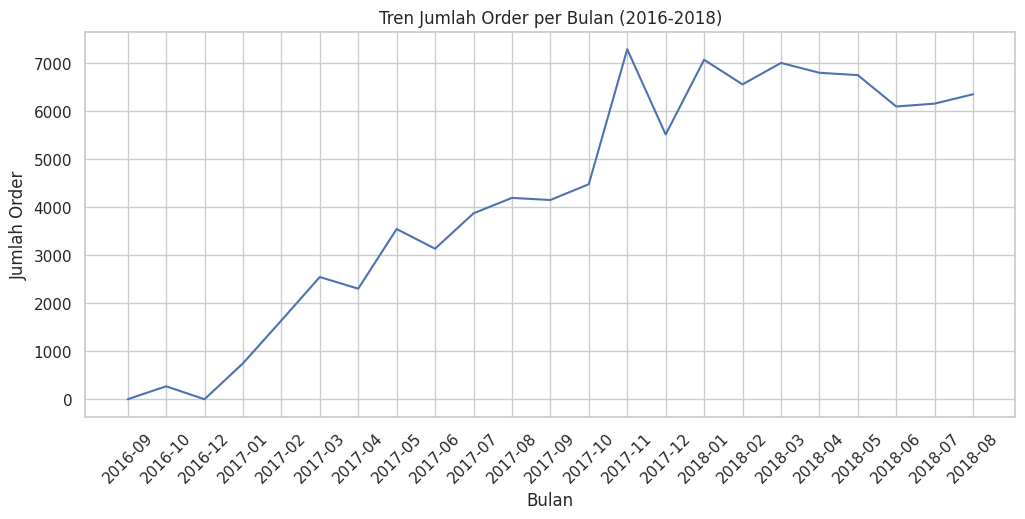

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(monthly_orders['order_month'], monthly_orders['order_id'])
plt.xticks(rotation=45)
plt.title("Tren Jumlah Order per Bulan (2016-2018)")
plt.xlabel("Bulan")
plt.ylabel("Jumlah Order")
plt.show()

Insight:
- Jumlah pesanan menunjukkan tren meningkat dari tahun ke tahun.
- Terdapat fluktuasi pada beberapa bulan, namun secara keseluruhan mengalami pertumbuhan.
- Hal ini mengindikasikan peningkatan aktivitas transaksi pada platform

### Pertanyaan 2: Bagaimana distribusi metode pembayaran dan metode mana yang paling dominan?

In [48]:
payment_type_counts = order_payments_df['payment_type'].value_counts()

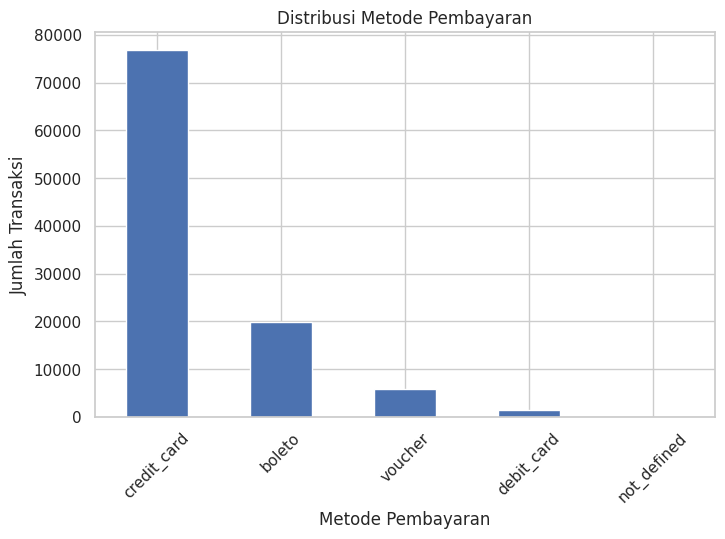

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
payment_type_counts.plot(kind='bar')
plt.title("Distribusi Metode Pembayaran")
plt.xlabel("Metode Pembayaran")
plt.ylabel("Jumlah Transaksi")
plt.xticks(rotation=45)
plt.show()

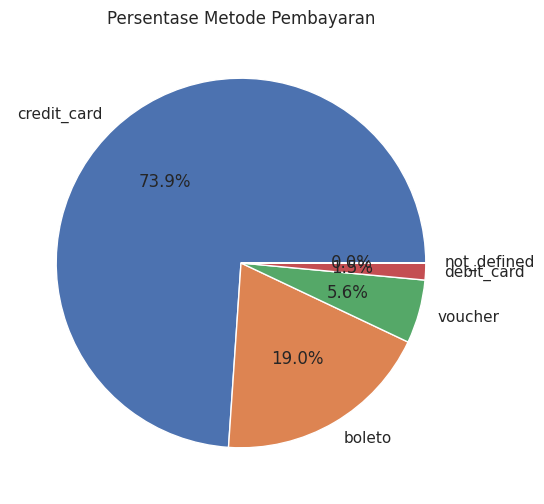

In [50]:
plt.figure(figsize=(6,6))
payment_type_counts.plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.title("Persentase Metode Pembayaran")
plt.show()

Insight:
- Metode pembayaran didominasi oleh credit_card dengan jumlah transaksi paling tinggi.
- Metode lain seperti boleto dan voucher digunakan namun dengan proporsi yang lebih kecil.
- Hal ini menunjukkan bahwa pelanggan cenderung memilih metode pembayaran yang praktis dan fleksibel.

## Analisis Lanjutan (Opsional)

Selain melihat distribusi jumlah transaksi berdasarkan metode pembayaran, analisis juga dapat diperluas dengan melihat total nilai transaksi pada setiap metode pembayaran.

In [51]:
payment_summary = order_payments_df.groupby('payment_type')['payment_value'].sum().sort_values(ascending=False)
payment_summary

,payment_value
payment_type,
credit_card,12528520.11
boleto,2869361.27
voucher,379436.87
debit_card,217989.79
not_defined,0.00


Insight:
- Metode pembayaran credit_card tidak hanya dominan dari sisi jumlah transaksi, tetapi juga dari total nilai pembayaran.
- Metode lain seperti boleto dan voucher memiliki kontribusi yang lebih kecil terhadap total transaksi.
- Hal ini menunjukkan bahwa metode pembayaran digital lebih diminati dan memiliki kontribusi besar terhadap pendapatan platform.

## Conclusion

- Conclusion pertanyaan 1:
  Tren jumlah pesanan pada platform e-commerce menunjukkan peningkatan dari tahun 2016 hingga 2018. Meskipun terdapat fluktuasi pada beberapa periode, secara keseluruhan terjadi pertumbuhan jumlah transaksi yang menunjukkan perkembangan bisnis yang positif.

- Conclusion pertanyaan 2:
  Metode pembayaran didominasi oleh credit_card baik dari sisi jumlah transaksi maupun total nilai pembayaran. Hal ini menunjukkan bahwa pelanggan cenderung memilih metode pembayaran yang praktis, cepat, dan fleksibel.

## Conclusion & Recommendation

### 📈 1. Tren Jumlah Pesanan Bulanan
**Kesimpulan:**
Berdasarkan hasil analisis, jumlah pesanan pada platform e-commerce menunjukkan pola fluktuatif dari tahun 2016 hingga 2018. Terdapat beberapa periode dengan peningkatan signifikan yang mengindikasikan adanya lonjakan permintaan, kemungkinan dipengaruhi oleh faktor musiman atau campaign tertentu.

**Rekomendasi:**
- Perusahaan dapat memanfaatkan periode dengan lonjakan pesanan untuk mengoptimalkan strategi promosi dan pemasaran.
- Menyiapkan stok barang serta sistem logistik yang lebih baik pada periode dengan permintaan tinggi.
- Melakukan analisis lanjutan untuk mengidentifikasi faktor penyebab peningkatan pesanan, seperti event atau campaign tertentu.

---

### 💳 2. Distribusi Metode Pembayaran
**Kesimpulan:**
Distribusi metode pembayaran menunjukkan bahwa credit card merupakan metode yang paling dominan digunakan oleh pelanggan. Sementara itu, metode pembayaran lain seperti boleto dan voucher memiliki tingkat penggunaan yang lebih rendah.

**Rekomendasi:**
- Mengoptimalkan sistem pembayaran credit card untuk meningkatkan kenyamanan dan kecepatan transaksi.
- Memberikan promosi atau insentif pada metode pembayaran lain untuk meningkatkan variasi penggunaan.
- Mengevaluasi pengalaman pengguna pada metode pembayaran yang kurang populer guna meningkatkan adopsi pengguna.


## Data Preparation for Dashboard

In [52]:
# MAIN DATA 1 - Monthly Orders
orders_df['order_purchase_timestamp'] = pd.to_datetime(orders_df['order_purchase_timestamp'])
orders_df['order_month'] = orders_df['order_purchase_timestamp'].dt.to_period('M')

monthly_orders = orders_df.groupby('order_month')['order_id'].nunique().reset_index()
monthly_orders['order_month'] = monthly_orders['order_month'].astype(str)

monthly_orders.to_csv('main_data_orders.csv', index=False)


# MAIN DATA 2 - Payment Distribution
payment_distribution = order_payments_df['payment_type'].value_counts().reset_index()
payment_distribution.columns = ['payment_type', 'total']

payment_distribution.to_csv('main_data_payment.csv', index=False)